In [1]:
# Install required libraries
!pip install librosa -q

print("✅ Libraries installed!")

✅ Libraries installed!


In [2]:
# Libraries Import
import librosa
import librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported!")

✅ All libraries imported!


In [3]:
# RAVDESS Dataset download karo
!pip install kaggle -q

# Dataset seedha download karo
!wget -q "https://zenodo.org/record/1188976/files/Audio_Speech_Actors_01-24.zip"
!unzip -q Audio_Speech_Actors_01-24.zip -d ravdess_data

print("✅ Dataset downloaded!")
print("Files:", os.listdir('ravdess_data'))

✅ Dataset downloaded!
Files: ['Actor_21', 'Actor_18', 'Actor_04', 'Actor_22', 'Actor_19', 'Actor_01', 'Actor_02', 'Actor_16', 'Actor_08', 'Actor_06', 'Actor_07', 'Actor_15', 'Actor_14', 'Actor_24', 'Actor_12', 'Actor_03', 'Actor_11', 'Actor_05', 'Actor_20', 'Actor_23', 'Actor_17', 'Actor_10', 'Actor_09', 'Actor_13']


In [4]:
# Audio files aur emotions load karo
def get_emotion(filename):
    # RAVDESS filename format: 03-01-06-01-02-01-12.wav
    # 3rd number = emotion
    emotion_map = {
        '01': 'neutral',
        '02': 'calm',
        '03': 'happy',
        '04': 'sad',
        '05': 'angry',
        '06': 'fearful',
        '07': 'disgust',
        '08': 'surprised'
    }
    emotion_code = filename.split('-')[2]
    return emotion_map.get(emotion_code, 'unknown')

# Sari files collect karo
audio_files = []
emotions = []

for actor in os.listdir('ravdess_data'):
    actor_path = f'ravdess_data/{actor}'
    if os.path.isdir(actor_path):
        for file in os.listdir(actor_path):
            if file.endswith('.wav'):
                audio_files.append(f'{actor_path}/{file}')
                emotions.append(get_emotion(file))

print(f"✅ Total files: {len(audio_files)}")
print("Emotion distribution:")
print(pd.Series(emotions).value_counts())

✅ Total files: 1440
Emotion distribution:
disgust      192
sad          192
angry        192
surprised    192
calm         192
happy        192
fearful      192
neutral       96
Name: count, dtype: int64


In [5]:
# MFCC Features Extract karo
def extract_mfcc(filepath):
    audio, sr = librosa.load(filepath, duration=3, offset=0.5)
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
    return np.mean(mfcc.T, axis=0)

# Sab files se features nikalo
print("Extracting features... thoda wait karo ⏳")
X = []
for file in audio_files:
    features = extract_mfcc(file)
    X.append(features)

X = np.array(X)
y = np.array(emotions)

print(f"✅ Features shape: {X.shape}")
print(f"✅ Labels shape: {y.shape}")

Extracting features... thoda wait karo ⏳
✅ Features shape: (1440, 40)
✅ Labels shape: (1440,)


In [6]:
# Model Training
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# Encoding
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42)

# MLP Model
model = MLPClassifier(hidden_layer_sizes=(256, 128),
                      max_iter=300, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("\n", classification_report(y_test, y_pred,
      target_names=le.classes_))

✅ Accuracy: 0.6666666666666666

               precision    recall  f1-score   support

       angry       0.73      0.80      0.77        41
        calm       0.72      0.85      0.78        39
     disgust       0.66      0.59      0.62        39
     fearful       0.67      0.63      0.65        41
       happy       0.61      0.59      0.60        34
     neutral       0.47      0.50      0.48        14
         sad       0.73      0.57      0.64        42
   surprised       0.62      0.68      0.65        38

    accuracy                           0.67       288
   macro avg       0.65      0.65      0.65       288
weighted avg       0.67      0.67      0.66       288



In [7]:
# Better Features - MFCC + Chroma + Mel Spectrogram
def extract_features_v2(filepath):
    audio, sr = librosa.load(filepath, duration=3, offset=0.5)

    # MFCC
    mfcc = np.mean(librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40).T, axis=0)
    # Chroma
    chroma = np.mean(librosa.feature.chroma_stft(y=audio, sr=sr).T, axis=0)
    # Mel Spectrogram
    mel = np.mean(librosa.feature.melspectrogram(y=audio, sr=sr).T, axis=0)

    return np.hstack([mfcc, chroma, mel])

print("Extracting better features... ⏳")
X2 = [extract_features_v2(f) for f in audio_files]
X2 = np.array(X2)
print(f"✅ New features shape: {X2.shape}")

Extracting better features... ⏳
✅ New features shape: (1440, 180)


In [8]:
# Better Model with improved features
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# Scaling
scaler2 = StandardScaler()
X2_scaled = scaler2.fit_transform(X2)

# Split
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2_scaled, y_encoded, test_size=0.2, random_state=42)

# Better MLP Model
model2 = MLPClassifier(
    hidden_layer_sizes=(512, 256, 128),
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)
model2.fit(X_train2, y_train2)
y_pred2 = model2.predict(X_test2)

print("✅ Accuracy:", accuracy_score(y_test2, y_pred2))
print("\n", classification_report(y_test2, y_pred2,
      target_names=le.classes_))

✅ Accuracy: 0.6493055555555556

               precision    recall  f1-score   support

       angry       0.85      0.80      0.82        41
        calm       0.78      0.79      0.78        39
     disgust       0.70      0.67      0.68        39
     fearful       0.61      0.54      0.57        41
       happy       0.56      0.44      0.49        34
     neutral       0.32      0.57      0.41        14
         sad       0.64      0.67      0.65        42
   surprised       0.60      0.63      0.62        38

    accuracy                           0.65       288
   macro avg       0.63      0.64      0.63       288
weighted avg       0.66      0.65      0.65       288



In [9]:
# Confusion Matrix - Pehle wale model ki
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Emotion Recognition - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Model Save
import joblib
joblib.dump(model, 'emotion_model.pkl')
joblib.dump(scaler, 'emotion_scaler.pkl')
joblib.dump(le, 'emotion_encoder.pkl')
print("✅ Model saved!")

NameError: name 'confusion_matrix' is not defined

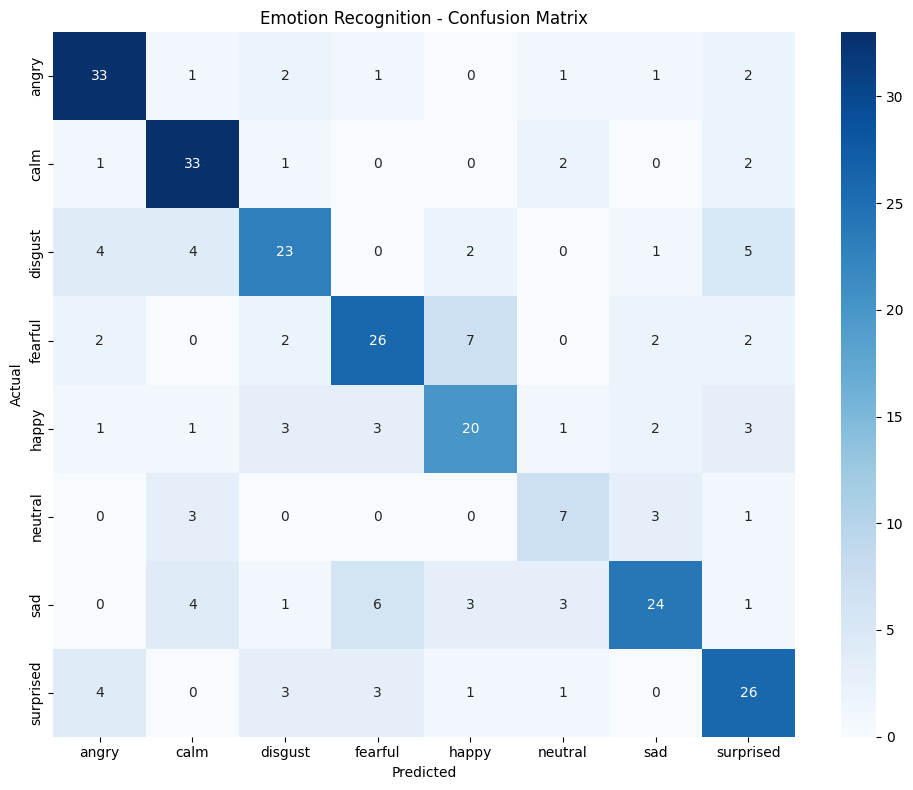

✅ Model saved!


In [10]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Emotion Recognition - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

import joblib
joblib.dump(model, 'emotion_model.pkl')
joblib.dump(scaler, 'emotion_scaler.pkl')
joblib.dump(le, 'emotion_encoder.pkl')
print("✅ Model saved!")

In [11]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest Model
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("✅ Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("\n", classification_report(y_test, rf_pred,
      target_names=le.classes_))

✅ Random Forest Accuracy: 0.6354166666666666

               precision    recall  f1-score   support

       angry       0.80      0.68      0.74        41
        calm       0.58      0.92      0.71        39
     disgust       0.55      0.54      0.55        39
     fearful       0.69      0.66      0.68        41
       happy       0.56      0.44      0.49        34
     neutral       0.56      0.36      0.43        14
         sad       0.70      0.50      0.58        42
   surprised       0.62      0.79      0.70        38

    accuracy                           0.64       288
   macro avg       0.63      0.61      0.61       288
weighted avg       0.64      0.64      0.63       288

